### Setup — imports and project paths

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

# Resolve project root whether the notebook runs from repo root or notebooks/
_cwd = Path.cwd()
if (_cwd / "data" / "processed").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data" / "processed").exists():
    PROJECT_ROOT = _cwd.parent
else:
    raise FileNotFoundError(
        "Could not find data/processed/. Run the notebook from the project root "
        "or from the notebooks/ directory."
    )

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(exist_ok=True)

### 1. Low-review rate by delivery-delay bucket

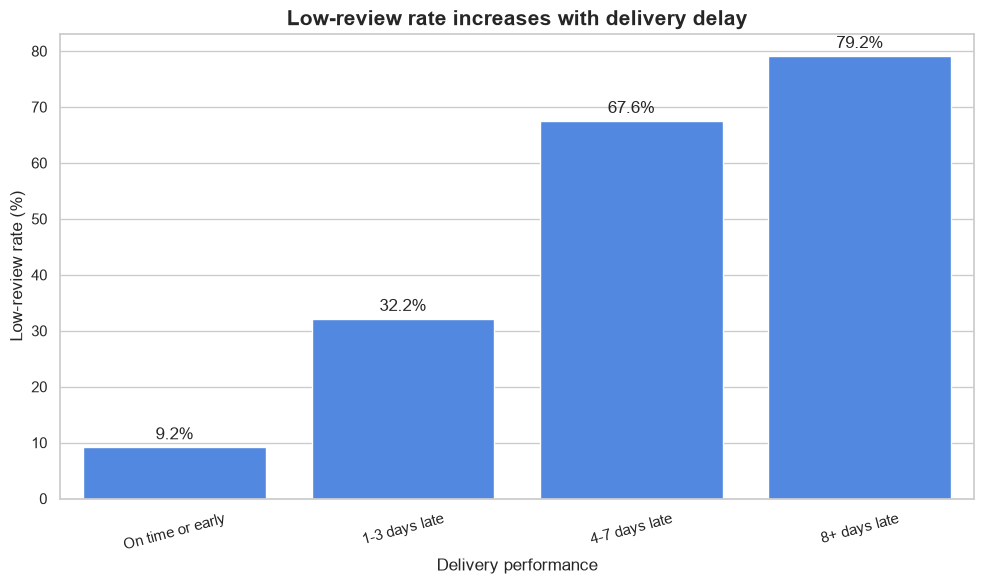

In [7]:
delivery = pd.read_csv(DATA_DIR / "delivery_review_analysis.csv")

bucket_order = [
    "On time or early",
    "1-3 days late",
    "4-7 days late",
    "8+ days late"
]

delivery["delivery_bucket"] = pd.Categorical(
    delivery["delivery_bucket"],
    categories=bucket_order,
    ordered=True
)

delivery = delivery.sort_values("delivery_bucket")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=delivery,
    x="delivery_bucket",
    y="low_review_rate_pct",
    color="#3B82F6"
)

plt.title(
    "Low-review rate increases with delivery delay",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Delivery performance")
plt.ylabel("Low-review rate (%)")
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "delivery_delay_vs_reviews.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** Orders delivered late have a higher low-review rate than orders
delivered on time or early. This is an observational relationship and does not prove
that delay alone causes poor reviews.

### 2. Product categories with the highest low-review rate

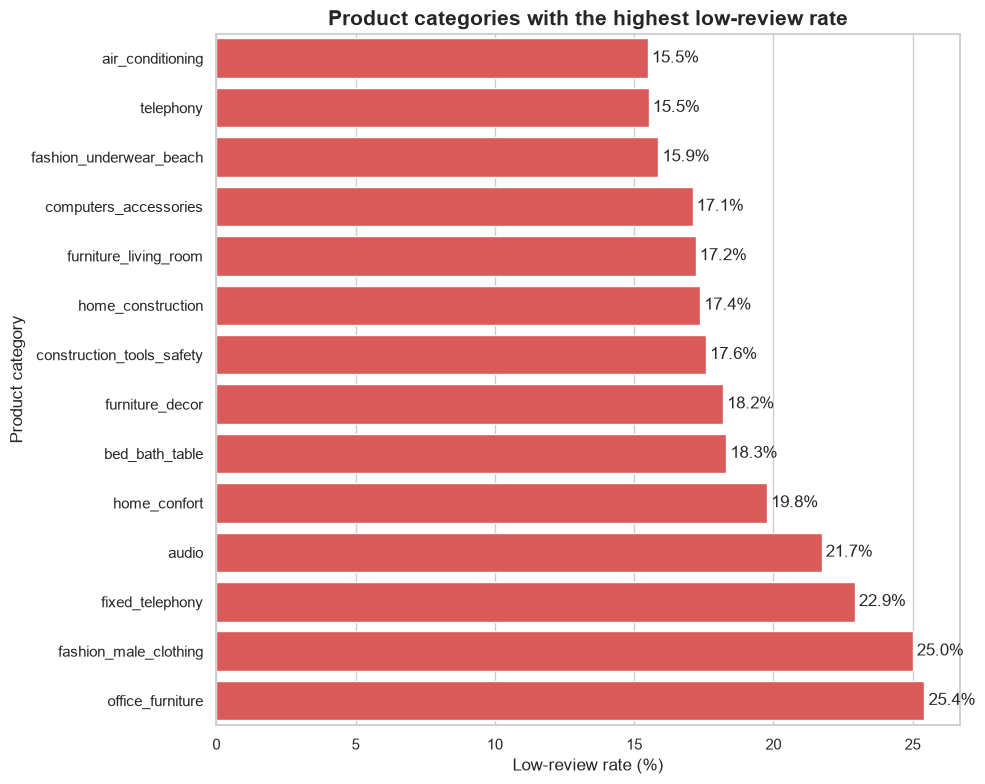

In [11]:
category = pd.read_csv(DATA_DIR / "category_review_analysis.csv")

category = category.sort_values(
    "low_review_rate_pct",
    ascending=True
)

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=category,
    x="low_review_rate_pct",
    y="category",
    color="#EF4444"
)

plt.title(
    "Product categories with the highest low-review rate",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Low-review rate (%)")
plt.ylabel("Product category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "category_low_review_risk.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### 3. Repeat-purchase rate by first-order review score

/tmp/ipykernel_36159/3633180618.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


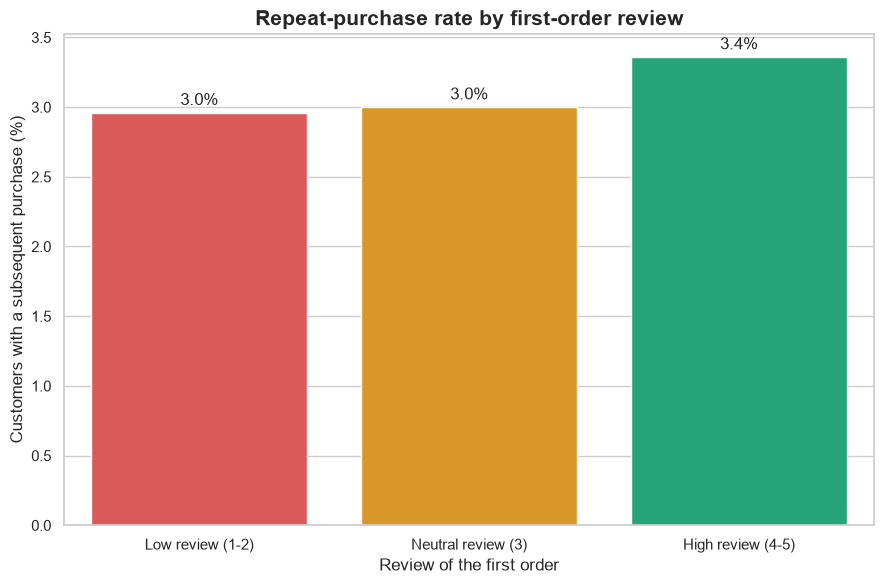

In [9]:
repeat = pd.read_csv(DATA_DIR / "repeat_purchase_analysis.csv")

review_order = [
    "Low review (1-2)",
    "Neutral review (3)",
    "High review (4-5)"
]

repeat["first_order_review_group"] = pd.Categorical(
    repeat["first_order_review_group"],
    categories=review_order,
    ordered=True
)

repeat = repeat.sort_values("first_order_review_group")

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=repeat,
    x="first_order_review_group",
    y="repeat_purchase_rate_pct",
    palette=["#EF4444", "#F59E0B", "#10B981"]
)

plt.title(
    "Repeat-purchase rate by first-order review",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Review of the first order")
plt.ylabel("Customers with a subsequent purchase (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "repeat_purchase_by_review.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### 4. Sellers with the highest low-review rate

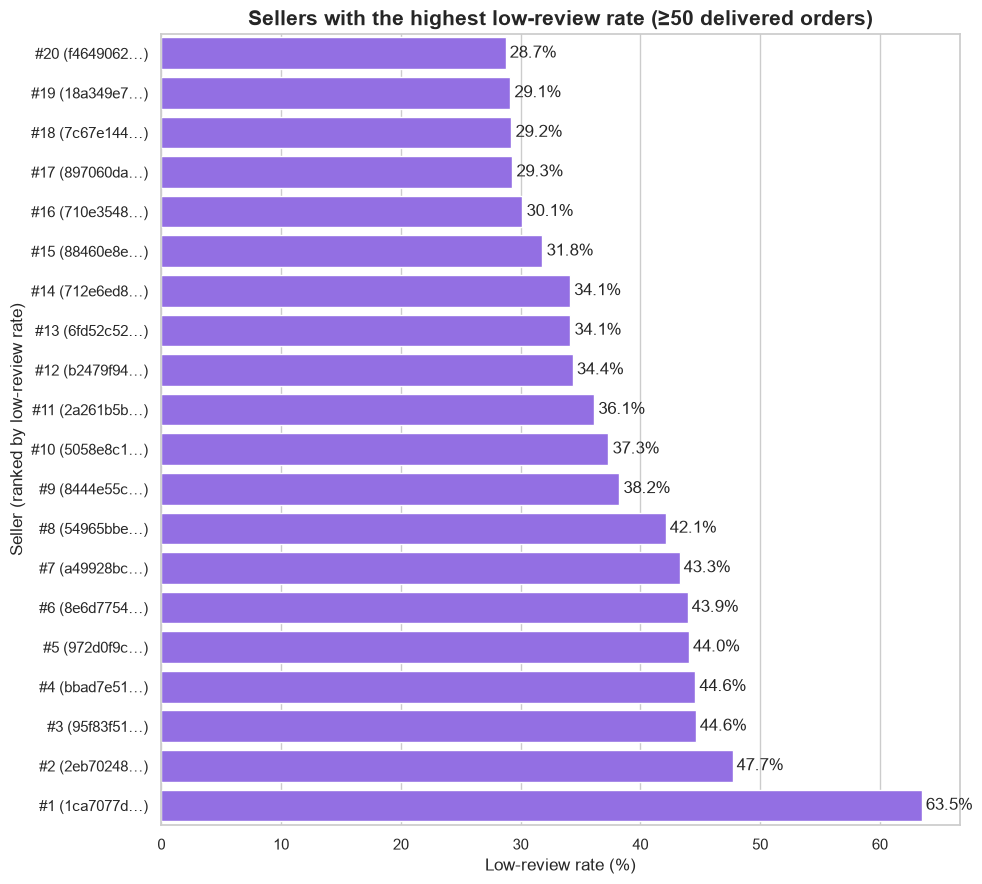

In [12]:
sellers = pd.read_csv(DATA_DIR / "sellers_analysis.csv")

sellers = sellers.sort_values(
    "low_review_rate_pct",
    ascending=False
)
sellers["seller_label"] = [
    f"#{rank} ({seller_id[:8]}…)"
    for rank, seller_id in enumerate(sellers["seller_id"], start=1)
]
sellers = sellers.sort_values("low_review_rate_pct", ascending=True)

plt.figure(figsize=(10, 9))

ax = sns.barplot(
    data=sellers,
    x="low_review_rate_pct",
    y="seller_label",
    color="#8B5CF6"
)

plt.title(
    "Sellers with the highest low-review rate (≥50 delivered orders)",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Low-review rate (%)")
plt.ylabel("Seller (ranked by low-review rate)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "seller_low_review_risk.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** A small subset of sellers account for a disproportionately high share of low reviews. The worst-performing seller has a low-review rate above 60%, well above the marketplace average (~13%). These sellers may warrant operational review, coaching, or tighter performance monitoring.